## SmartTel Retention Intelligence: A Decision Intelligence Platform for Telecom Customer Retention

### Introduction

Customer retention has become one of the most important strategic priorities in the telecommunications industry. Acquiring new customers is significantly more expensive than retaining existing ones, making customer churn a direct threat to recurring revenue and long-term profitability. While predicting which customers are likely to leave is valuable, effective retention requires a deeper understanding of customer behavior, service usage patterns, and the factors that contribute to churn.

This project, SmartTel Retention Intelligence, aims to develop an end-to-end decision intelligence system that helps telecom providers identify customers at risk of churning, understand the drivers behind churn, prioritize high-value customers, and support data-driven retention strategies. Rather than treating churn prediction as a standalone machine learning problem, the project frames it as a business decision-making challenge where marketing budgets, customer value, and intervention effectiveness must all be considered.

The analysis uses the IBM Telco Customer Churn dataset, a widely used benchmark dataset containing demographic information, subscribed services, account details, billing information, and churn status for over 7,000 telecom customers. The target variable is Churn, indicating whether a customer discontinued the service.

### Business problem

The telecom company wishes to reduce customer churn using data-driven decision making.
Rather than contacting every customer with expensive retention campaigns, the business wants to identify customers most likely to churn and allocate marketing resources efficiently. Before predictive models can be trusted, the underlying data must be evaluated for completeness, consistency, accuracy and suitability.

#### Project Goal

To develop an end-to-end, explainable decision intelligence platform that enables telecom companies to proactively reduce customer churn by identifying at-risk customers, understanding the drivers of churn, prioritizing high-value retention opportunities, and estimating the financial impact of targeted retention strategies.

#### Project Objectives

- Reduce customer churn by identifying customers who are most likely to discontinue their services before they leave.
- Improve retention decision-making by providing actionable insights into the key factors influencing customer churn.
- Increase the effectiveness of retention campaigns by prioritizing customers who are both at high risk of churn and valuable to the business.
- Optimize the allocation of marketing resources by identifying where retention efforts are likely to generate the highest business returns.
- Minimize revenue loss associated with customer churn through early intervention and targeted retention strategies.
- Support strategic business planning by enabling stakeholders to simulate different retention scenarios and evaluate their financial impact before implementation.
-- 


#### Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
from kagglehub import KaggleDatasetAdapter

import warnings
warnings.filterwarnings('ignore')
import os


#### Load the Dataset

In [3]:
# Set the path to the file you'd like to load
file_path = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "blastchar/telco-customer-churn",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:\n",  df.head())

    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pap

In [4]:
df.shape

(7043, 21)

The dataset contains 7,043 customer records and 21 attributes describing customer demographics, subscribed services, billing information, and churn status.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

Two things to flag :
- `TotalCharges` is loaded as an **object** (string), not numeric — it should be numeric and will need cleaning.
- `SeniorCitizen` is encoded as `0`/`1` (int) while other binary fields (`Partner`, `Dependents`, etc.) are `Yes`/`No` strings — worth normalizing later for consistency.


### Missing-Value Analysis

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
# 
target_cols = ['SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

# Creates a dictionary where key = column name, value = unique values
unique_values_dict = {col: df[col].unique() for col in target_cols}

# Print the results nicely
for col, values in unique_values_dict.items():
    print(f"Unique values in '{col}': {values}\n")

Unique values in 'SeniorCitizen': [0 1]

Unique values in 'Partner': <StringArray>
['Yes', 'No']
Length: 2, dtype: str

Unique values in 'Dependents': <StringArray>
['No', 'Yes']
Length: 2, dtype: str

Unique values in 'tenure': [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]

Unique values in 'PhoneService': <StringArray>
['No', 'Yes']
Length: 2, dtype: str

Unique values in 'MultipleLines': <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

Unique values in 'InternetService': <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

Unique values in 'OnlineSecurity': <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

Unique values in 'OnlineBackup': <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

Unique values in 'DeviceProtection': <S

In [9]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce") #convert from strings to float

In [10]:
print(df['TotalCharges'].dtype)


float64


In [11]:
blank_total_charges = df["TotalCharges"].isnull().sum()
print(f"Rows with unparseable TotalCharges: {blank_total_charges}")

df.loc[df["TotalCharges"].isnull(), ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

Rows with unparseable TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


Every row with a missing `TotalCharges` has **`tenure == 0`** — these are brand-new customers who haven't been billed a full cycle yet. This isn't random missingness; it's structural, and the right treatment is to impute `TotalCharges = 0` for these rows (consistent with zero tenure) rather than drop them or impute a mean, which would misrepresent brand-new customers as long-tenured ones.


In [12]:
df["TotalCharges"] = df["TotalCharges"].fillna(0) # fill missing values with zero

In [14]:
print(df.duplicated().sum())

0


### Analysis of Class imbalance on Target

       count    pct
Churn              
No      5174  73.46
Yes     1869  26.54


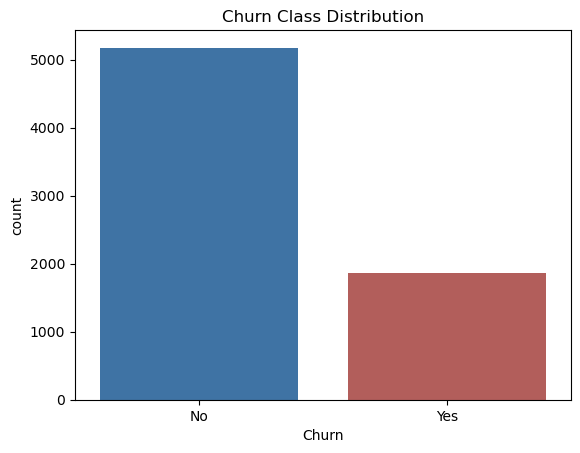

In [21]:
churn_counts = df["Churn"].value_counts()
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

summary = pd.DataFrame({"count": churn_counts, "pct": churn_percentage.round(2)}) # converts the percentage and counts to a data frame for comparison
print(summary)

fig, ax = plt.subplots()
sns.countplot(data=df, x="Churn", hue="Churn", palette=["#2E74B5", "#C0504D"], legend=False, ax=ax)
ax.set_title("Churn Class Distribution")
plt.show()

This indicates a moderate class imbalance with churn rate at 26%. this inform usage of ROC-AUC curve and PR-AUC curve since accuracy will be informed majorly by the majority which is h=the NO class